In [1]:
import pandas as pd

ratings = pd.read_csv('../data/ratings.csv')
movies = pd.read_csv('../data/movies.csv')

df = ratings.merge(movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [3]:
df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [4]:
df.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [5]:
df['timestamp']=pd.to_datetime(df['timestamp'], unit='s')

In [6]:
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [7]:
df['day'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day'].apply(lambda x: 1 if x >= 5 else 0)

In [8]:
df['hour'] = df['timestamp'].dt.hour

In [9]:
def get_time_of_day(hour):
    if hour<12:
        return 'morning'
    elif hour<18:
        return 'afternoon'
    else:
        return 'night'
df['time_of_day'] = df['hour'].apply(get_time_of_day)

In [10]:
df.sample(5)

,userId,movieId,rating,timestamp,title,genres,day,is_weekend,hour,time_of_day
88110,567,141668,0.5,2018-05-02 19:40:11,War Room (2015),Drama,2,0,19,night
33121,226,595,2.5,2004-09-20 06:44:01,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX,0,0,6,morning
29577,202,1639,4.0,2000-11-22 20:36:43,Chasing Amy (1997),Comedy|Drama|Romance,2,0,20,night
77254,483,223,3.5,2007-05-04 15:46:50,Clerks (1994),Comedy,4,0,15,afternoon
26886,182,5323,0.5,2003-06-09 10:18:37,Jason X (2002),Horror|Sci-Fi|Thriller,0,0,10,morning


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

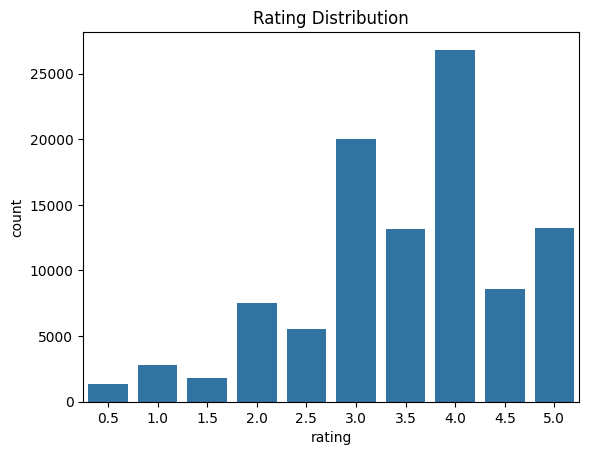

In [12]:
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()

In [13]:
# Top Movies
df['title'].value_counts().head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: count, dtype: int64

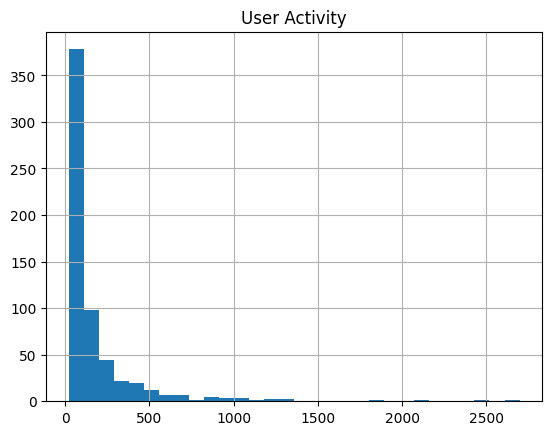

In [14]:
# User Activity
df['userId'].value_counts().hist(bins=30)
plt.title("User Activity")
plt.show()

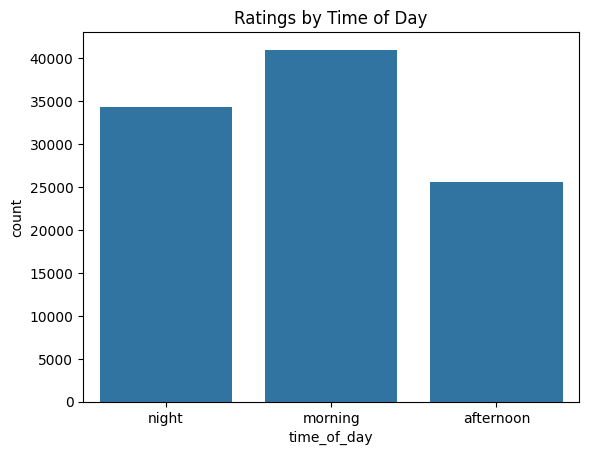

In [15]:
#Time-Based Analysis
sns.countplot(x='time_of_day', data=df)
plt.title("Ratings by Time of Day")
plt.show()

In [16]:
# Genre Analysis
genres = df['genres'].str.split('|').explode()
genres.value_counts().head(10)

genres
Drama        41928
Comedy       39053
Action       30635
Thriller     26452
Adventure    24161
Romance      18124
Sci-Fi       17243
Crime        16681
Fantasy      11834
Children      9208
Name: count, dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df['rating'].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [19]:
df['userId'].nunique()

610

In [20]:
df['movieId'].nunique()

9724

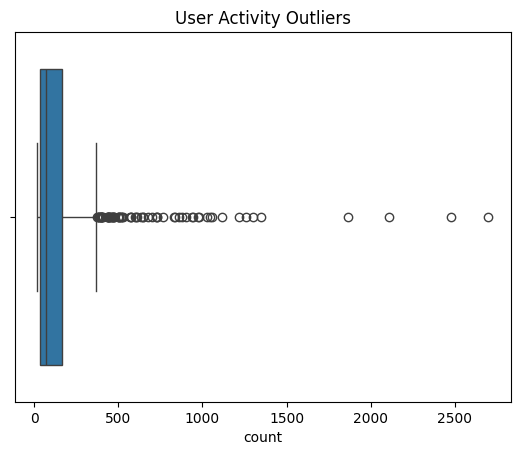

In [21]:
user_counts = df['userId'].value_counts()
sns.boxplot(x = user_counts)
plt.title("User Activity Outliers")
plt.show()

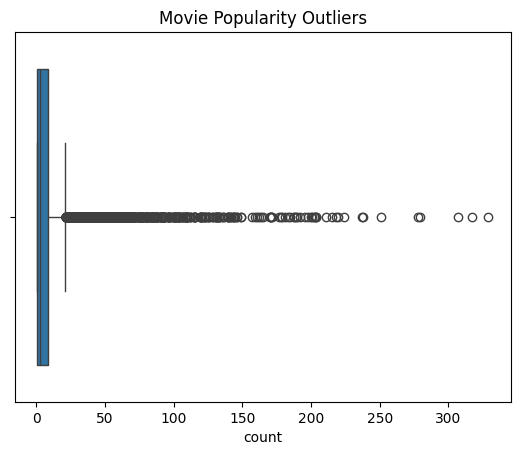

In [22]:
movie_counts = df['movieId'].value_counts()
sns.boxplot(x = movie_counts)
plt.title('Movie Popularity Outliers')
plt.show()

### “Outlier analysis revealed highly active users and highly rated movies. These are not anomalies but reflect real-world user behavior and item popularity. Therefore, no outlier removal was performed.”

## **PHASE 2 - Modeling**

In [23]:
#!pip install 'numpy<2'

In [24]:
#!pip install scikit-surprise

In [25]:
from surprise import Dataset, Reader

data = df[['userId', 'movieId', 'rating']]
reader = Reader(rating_scale=(0.5, 5.0))
dataset = Dataset.load_from_df(data, reader)

In [26]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)

In [27]:
# Train Model
from surprise import SVD

model = SVD()
model.fit(trainset)

In [28]:
from surprise import accuracy

predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8765


0.8764840745081487

In [29]:
# Build Recommendation Function
def recommend_movies(user_id, df, model, n=5):
  movie_ids = df['movieId'].unique()
  watched = df[df['userId'] == user_id]['movieId'].values

  predictions = []

  for movie_id in movie_ids:
    if movie_id not in watched:
      pred = model.predict(user_id, movie_id)
      predictions.append((movie_id, pred.est))
  predictions.sort(key=lambda x: x[1], reverse=True)
  return predictions[:n]

In [30]:
# Convert IDs ➡️ Movie Names
def get_movie_titles(recommendations, movies):
    movie_map = dict(zip(movies['movieId'], movies['title']))

    titles = []
    for mid, _ in recommendations:
        if mid in movie_map:
            titles.append(movie_map[mid])

    return titles

In [31]:
recs = recommend_movies(10, df, model, n=5)
get_movie_titles(recs, movies)

['Star Wars: Episode IV - A New Hope (1977)',
 'Shawshank Redemption, The (1994)',
 'Office Space (1999)',
 'Being John Malkovich (1999)',
 "Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)"]

### “An SVD-based collaborative filtering model was implemented using the Surprise library. The model achieved an RMSE of 0.8808, serving as a baseline for further improvements using hybrid approaches.”

## Build Hybrid Model

In [32]:
def get_svd_predictions(df, model):
  preds = []
  for row in df.itertuples():
    pred = model.predict(row.userId, row.movieId).est
    preds.append(pred)

  df['svd_pred'] = preds
  return df
df = get_svd_predictions(df, model)

In [33]:
# Time of Day Encoding

df = pd.get_dummies(df, columns=['time_of_day'], drop_first=True)

In [34]:
# Encode Genres
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_endoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df, genre_endoded], axis=1)
df.drop('genres', axis=1, inplace=True)

In [ ]:
movie_stats = df.groupby('movieId').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'num_ratings']
df = df.merge(movie_stats, on='movieId', how = 'left')

In [36]:
df.head()

,userId,movieId,rating,timestamp,title,day,is_weekend,hour,svd_pred,time_of_day_morning,...,o,r,s,t,u,v,y,|,avg_rating,num_rating
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),6,1,18,4.423875,False,...,1,1,1,1,1,1,1,1,3.920930,215
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),6,1,18,3.915253,False,...,1,0,0,0,0,0,1,1,3.259615,52
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),6,1,18,4.531995,False,...,1,1,0,1,0,0,0,1,3.946078,102
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),6,1,19,4.678790,False,...,0,1,1,1,0,0,1,1,3.975369,203
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",6,1,18,4.856891,False,...,0,1,1,1,0,0,1,1,4.237745,204


In [ ]:
features = ['svd_pred', 'is_weekend', 'avg_rating', 'num_ratings'] + list(mlb.classes_)

In [38]:
features += [col for col in df.columns if 'time_of_day_' in col]

In [39]:
# Target
x = df[features]
y = df['rating']

In [40]:
# Train Modle (XGBoost)
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_hybrid =  XGBRegressor(n_estimators=100, max_depth=6)
model_hybrid.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [41]:
# Evaluate Hybrid Model
from sklearn.metrics import mean_squared_error
import numpy as np

preds = model_hybrid.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'Hybrid RMSE: {rmse}')

Hybrid RMSE: 0.5915659277776834


In [42]:
def hybrid_recommend(user_id, df, model_svd, model_hybrid, n=5):
    movie_ids = df['movieId'].unique()
    watched = df[df['userId'] == user_id]['movieId'].values

    predictions = []

    for movie_id in movie_ids:
        if movie_id not in watched:

            # SVD prediction
            svd_pred = model_svd.predict(user_id, movie_id).est

            # Take one sample row for that movie
            row = df[df['movieId'] == movie_id].iloc[0].copy()

            row['svd_pred'] = svd_pred

            input_data = row[features].values.reshape(1, -1)
            final_pred = model_hybrid.predict(input_data)[0]

            predictions.append((movie_id, final_pred))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:n]

In [43]:
recs = hybrid_recommend(1, df, model, model_hybrid)
get_movie_titles(recs, movies)

['Switch, The (2010)',
 'My Man Godfrey (1957)',
 'Striking Distance (1993)',
 'Cocoon: The Return (1988)',
 'Long Goodbye, The (1973)']

In [52]:
df.to_csv('../data/final_df.csv', index=False)

In [ ]:
# !pip install shap

In [45]:
import shap

explainer = shap.TreeExplainer(model_hybrid)
shap_values = explainer.shap_values(x_test)

In [46]:
sample = x_test.iloc[:50]

In [47]:
shap_values = explainer(sample)

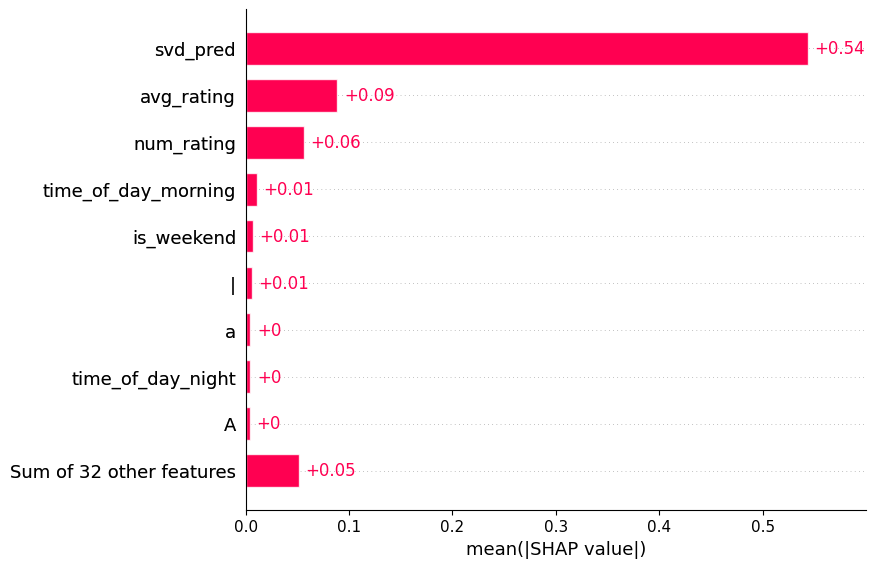

In [48]:
shap.plots.bar(shap_values)

**SHAP analysis revealed that SVD predictions are the most influential feature, indicating that collaborative filtering dominates the recommendation process. However, additional features such as average rating and number of ratings improve performance, while contextual features like time of day contribute marginally**

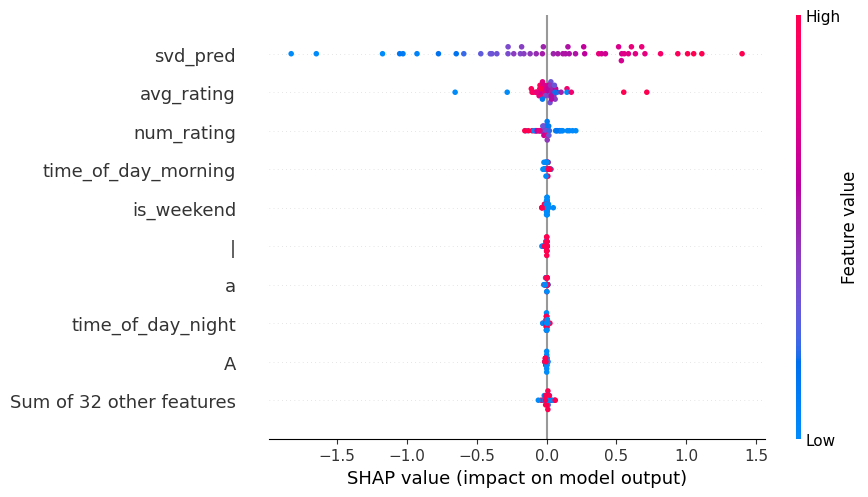

In [49]:
shap.plots.beeswarm(shap_values)

**The SHAP beeswarm plot shows that higher SVD predictions strongly increase recommendation scores, while lower values decrease them. Average rating also has a positive influence. Contextual features such as time of day and weekend have minimal impact, indicating that user behavior is the dominant factor in recommendations.**

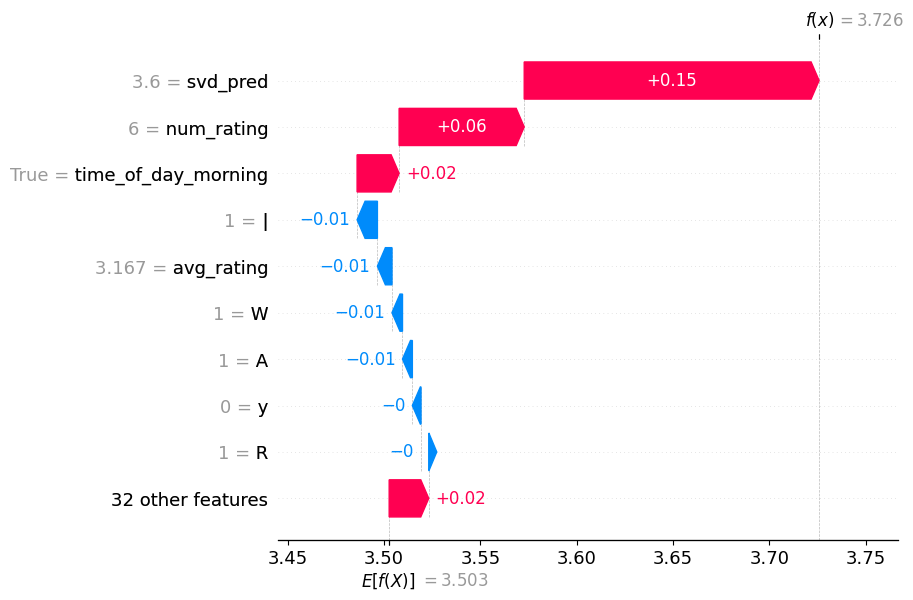

In [50]:
shap.plots.waterfall(shap_values[0])

**The SHAP waterfall plot explains individual predictions by showing feature contributions. For the selected example, the SVD prediction contributed the most to the final score, followed by popularity features. Contextual and genre features had smaller effects, demonstrating that collaborative filtering is the dominant factor.**